In [1]:
from PIL import Image
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 导入 MambaVision 模型
from vision.helper import load_model, load_param, load_label, preprocess_image, print_dict, load_from_hf

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 1. 加载模型，参数和标签


In [2]:
# 下载完成后，将输出粘贴到cell中，后续运行无需网络
# param_path, model_path = load_from_hf("nvidia/MambaVision-T-1K")
param_path = "/root/autodl-shared/hf_cache/hub/models--nvidia--MambaVision-T-1K/snapshots/b1de77e17599566d98efb701c0231b1095dc3a67/model.safetensors"
model_path = "/root/autodl-shared/hf_cache/hub/models--nvidia--MambaVision-T-1K/snapshots/b1de77e17599566d98efb701c0231b1095dc3a67/config.json"

In [3]:
model = load_model(model_path)
print(model)

MambaVision(
    # attributes
    dim = 80
    in_dim = 32
    depths = [1, 3, 8, 4]
    window_size = [8, 8, 14, 7]
    mlp_ratio = 4
    num_heads = [2, 4, 8, 16]
    num_classes = 1000
    layer_scale = None
    mean = Array([0.485, 0.456, 0.406], dtype=float32)
    std = Array([0.229, 0.224, 0.225], dtype=float32)
)


In [4]:
# labels = load_label(label_path)
labels = load_label(model_path, key='id2label')
print_dict({id:label for id,label in enumerate(labels[:5])})

0: tench, Tinca tinca
1: goldfish, Carassius auratus
2: great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias
3: tiger shark, Galeocerdo cuvieri
4: hammerhead, hammerhead shark


In [5]:
params = load_param(param_path)
print_dict(params)

params:
  Dense_0:
    bias: array(shape=(1000,), dtype=float32)
    kernel: array(shape=(640, 1000), dtype=float32)
  MambaVisionLayer_0:
    ConvBlock_0:
      Conv_0:
        bias: array(shape=(80,), dtype=float32)
        kernel: array(shape=(3, 3, 80, 80), dtype=float32)
      Conv_1:
        bias: array(shape=(80,), dtype=float32)
        kernel: array(shape=(3, 3, 80, 80), dtype=float32)
      BatchNorm_0:
        bias: array(shape=(80,), dtype=float32)
        scale: array(shape=(80,), dtype=float32)
      BatchNorm_1:
        bias: array(shape=(80,), dtype=float32)
        scale: array(shape=(80,), dtype=float32)
    Downsample_0:
      Conv_0:
        kernel: array(shape=(3, 3, 80, 160), dtype=float32)
  MambaVisionLayer_1:
    ConvBlock_0:
      Conv_0:
        bias: array(shape=(160,), dtype=float32)
        kernel: array(shape=(3, 3, 160, 160), dtype=float32)
      Conv_1:
        bias: array(shape=(160,), dtype=float32)
        kernel: array(shape=(3, 3, 160, 160), dtype=

## 2. 加载测试图像

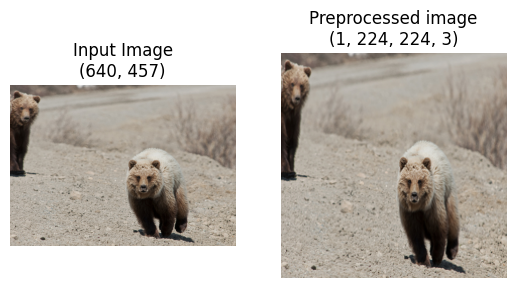

In [6]:
# 加载一张测试图像 (与原版示例相同的两只猫和沙发)
# url = 'http://images.cocodataset.org/val2017/000000020247.jpg'
image = Image.open("000000020247.jpg").convert('RGB')

# 在 Notebook 中展示图像
plt.subplot(1,2,1)
plt.imshow(image)
plt.axis('off')
plt.title(f"Input Image\n{image.size}")

# 预处理图像
input_size = (224, 224)
# image_net数据集的全局参数
mean = jnp.array([0.485, 0.456, 0.406])
std = jnp.array([0.229, 0.224, 0.225])

inputs = preprocess_image(image, input_size, mean, std)
# inputs = preprocess_image(image, input_size)  # 从图像计算参数

plt.subplot(1,2,2)
plt.axis('off')
plt.title(f"Preprocessed image\n{inputs.shape}")
# imshow不能接收标准化的输入，必须转换到归一化
plt.imshow(inputs[0]*std+mean)

plt.show()

## 3. 明文推理

In [7]:
logits = model.apply(params, inputs, train=False)

# 4. 获取预测结果
predicted_class_idx = jnp.argmax(logits, axis=-1).item()
predicted_label = labels[predicted_class_idx]

print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class label: {predicted_label}")

Predicted class index: 294
Predicted class label: brown bear, bruin, Ursus arctos


## 4. 密文推理

In [8]:
# 不这么做，运行中会卡在jit

def predict(params, inputs):
    logits = model.apply(params, inputs)
    return jnp.argmax(logits, axis=-1)

pred_id = predict(params, inputs).item()
print(labels[pred_id])

brown bear, bruin, Ursus arctos


In [9]:
import sml.utils.emulation as emulation

mode = emulation.Mode.MULTIPROCESS

# 2PC is prone to OOM! use at own risk!
# emulator = emulation.Emulator("2pc.json",mode)  # OOM!
emulator = emulation.Emulator("3pc.json",mode)  # 18GB

emulator.up()

[2026-04-20 18:00:31,676]-[INFO]-[emulation.py:112]: Start multiprocess cluster...
[2026-04-20 18:00:32,134] [ForkServerProcess-4] Starting grpc server at 127.0.0.1:61923
[2026-04-20 18:00:32,134] [ForkServerProcess-1] Starting grpc server at 127.0.0.1:61920
[2026-04-20 18:00:32,135] [ForkServerProcess-2] Starting grpc server at 127.0.0.1:61921
[2026-04-20 18:00:32,136] [ForkServerProcess-5] Starting grpc server at 127.0.0.1:61924
[2026-04-20 18:00:32,136] [ForkServerProcess-3] Starting grpc server at 127.0.0.1:61922
[2026-04-20 18:00:33,783] [ForkServerProcess-2] Run : builtin_spu_init at node:1
[2026-04-20 18:00:33,783] [ForkServerProcess-1] Run : builtin_spu_init at node:0
[2026-04-20 18:00:33,785] [ForkServerProcess-3] Run : builtin_spu_init at node:2
I0420 18:00:33.789422 294651     0 external/brpc~/src/brpc/server.cpp:1195] Server[yacl::link::transport::internal::ReceiverServiceImpl] is serving on port=61931.
W0420 18:00:33.789441 294651     0 external/brpc~/src/brpc/server.cpp:1

In [10]:
s_params, s_input_ids = emulator.seal(params, inputs)
result = emulator.run(predict)(s_params, s_input_ids)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
[2026-04-20 18:00:34,500] [ForkServerProcess-4] Run : <lambda> at node:3
[2026-04-20 18:00:34,520] [ForkServerProcess-4] Run : <lambda> at node:3
[2026-04-20 18:00:34,524] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,528] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,531] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,534] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,537] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,538] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,542] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,543] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,546] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,548] [Fork

[2026-04-20 18:00:34.638] [info] [thread_pool.cc:30] Create a fixed thread pool with size 19


[2026-04-20 18:00:34,840] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,843] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,845] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,848] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,849] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,852] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,853] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,856] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,858] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,861] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,863] [ForkServerProcess-4] RunR: builtin_fetch_meta at node:3
[2026-04-20 18:00:34,866] [ForkServerProcess-4] Run : make_shares at node:3
[2026-04-20 18:00:34,905] [ForkServerProcess-4

[2026-04-20 18:00:49.658] [info] [thread_pool.cc:30] Create a fixed thread pool with size 19
[2026-04-20 18:00:49.729] [info] [thread_pool.cc:30] Create a fixed thread pool with size 19
[2026-04-20 18:00:50.167] [info] [thread_pool.cc:30] Create a fixed thread pool with size 19
[2026-04-20 18:01:58.124] [info] [api.cc:172] [Profiling] SPU execution predict completed, input processing took 8.492e-05s, execution took 68.408856798s, output processing took 2.052e-06s, total time 68.40894377s.
[2026-04-20 18:01:58.135] [info] [api.cc:220] HLO profiling: total time 68.374619644
[2026-04-20 18:01:58.135] [info] [api.cc:223] - pphlo.exponential, executed 36 times, duration 23.029790399s, send bytes 3633073536 recv bytes 3347351744, send actions 2648, recv actions 2458
[2026-04-20 18:01:58.135] [info] [api.cc:223] - pphlo.tanh, executed 16 times, duration 11.87209511s, send bytes 1824399360 recv bytes 1615667200, send actions 821, recv actions 750
[2026-04-20 18:01:58.135] [info] [api.cc:223] -

[2026-04-20 18:01:58,172] [ForkServerProcess-1] RunR: builtin_fetch_meta at node:0
[2026-04-20 18:01:58,179] [ForkServerProcess-2] RunR: builtin_gc at node:1
[2026-04-20 18:01:58,180] [ForkServerProcess-4] RunR: builtin_gc at node:3
[2026-04-20 18:01:58,180] [ForkServerProcess-5] RunR: builtin_gc at node:4
[2026-04-20 18:01:58,181] [ForkServerProcess-3] RunR: builtin_gc at node:2
[2026-04-20 18:01:58,181] [ForkServerProcess-1] RunR: builtin_gc at node:0
[2026-04-20 18:01:58,213] [ForkServerProcess-1] RunR: builtin_gc at node:0
[2026-04-20 18:01:58,214] [ForkServerProcess-2] RunR: builtin_gc at node:1
[2026-04-20 18:01:58,214] [ForkServerProcess-4] RunR: builtin_gc at node:3
[2026-04-20 18:01:58,214] [ForkServerProcess-3] RunR: builtin_gc at node:2
[2026-04-20 18:01:58,214] [ForkServerProcess-5] RunR: builtin_gc at node:4
[2026-04-20 18:01:58,265] [ForkServerProcess-4] RunR: builtin_gc at node:3
[2026-04-20 18:01:58,266] [ForkServerProcess-1] RunR: builtin_gc at node:0
[2026-04-20 18:01

In [11]:
print(labels[result.item()])

brown bear, bruin, Ursus arctos


In [12]:
# # 1. 实例化 MambaVision-T 架构配置
# model = MambaVision(
#     dim=80,
#     in_dim=32,
#     depths=(1, 3, 8, 4),
#     num_heads=(2, 4, 8, 16),
#     window_size=(8, 8, 14, 7),
#     num_classes=1000
# )
#
# # 2. 随机初始化参数 (JAX/Flax 风格)
# print("Initializing model weights randomly...")
# rng = jax.random.PRNGKey(42)
# variables = model.init(rng, inputs, train=False)
#
# # 3. 前向传播 (推理)
# print("Running inference...")
# logits = model.apply(variables, inputs, train=False)
#
# # 4. 获取预测结果
# predicted_class_idx = jnp.argmax(logits, axis=-1).item()
# predicted_label = labels[predicted_class_idx]
#
# # 注意：由于模型是随机初始化的，输出的类别也会是随机的！
# print("="*40)
# print(f"Predicted class index: {predicted_class_idx}")
# print(f"Predicted class label: {predicted_label}")
# print("="*40)
# print("(Note: The prediction is random because the weights are randomly initialized, not pretrained.)")
#
# # 打印模型结构，用于调试参数转换
# print_dict(variables)